# 7. Auditoría de data leakage

El momento de predicción se fija **inmediatamente antes del alta**, cuando la
información generada durante la estancia ya está disponible pero el reingreso
futuro todavía no ocurrió. Se audita cada variable original y derivada,
identificadores, posibles proxies, AUC univariado, duplicados y pacientes
compartidos.

In [1]:
from pathlib import Path
import re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

project_root = Path.cwd().resolve()
while not (project_root / "_config.yml").exists():
    if project_root.parent == project_root:
        raise FileNotFoundError("No se encontró _config.yml. Ejecuta el notebook dentro de la carpeta del libro.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

for _folder in ("tables", "figures"):          # se crean si no existen
    (project_root / _folder).mkdir(exist_ok=True)

from src.project_utils import *

configure_plots()
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 70)
TABLES = project_root / "tables"

def md_out(text):
    display(Markdown(text))

train = load_train(include_terminal=True)      # aquí se audita la población completa de entrenamiento
frame = prepare_frame(train)
num_cols, cat_cols = column_types(frame)
y, groups = frame[TARGET], frame[GROUP_COL]

## 1. Disponibilidad al momento de predicción

`Sí` significa disponible antes del alta; `Revisar` señala que la fecha exacta
de cierre del registro puede depender del flujo del hospital; `No` identifica
objetivos o identificadores no aptos; `Solo agrupar` se reserva para
`patient_nbr`.

In [2]:
MEDS_SET = {"No", "Steady", "Up", "Down"}
def disponibilidad(c):
    if c == RAW_TARGET:
        return "No", "Es la fuente directa del objetivo futuro."
    if c == TARGET:
        return "No", "Es la variable objetivo derivada."
    if c == ID_COL:
        return "No", "Identificador del encuentro; puede codificar orden o sistema y no es una característica clínica."
    if c == GROUP_COL:
        return "Solo agrupar", "Identifica al paciente para split, CV y bootstrap; nunca entra al modelo."
    if c == "discharge_disposition_id":
        return "Sí, con cautela", "Se conoce al alta, pero puede identificar fallecimiento u hospicio y trivializar la no readmisión."
    if c in ("diag_1", "diag_2", "diag_3", "diag_1_grupo", "diag_2_grupo", "diag_3_grupo"):
        return "Revisar", "Diagnóstico registrado al cierre del encuentro; debe confirmarse que esté finalizado antes de emitir la predicción."
    if c == "age_mid":
        return "Sí", "Transformación determinística del rango de edad disponible."
    if c in ("number_outpatient", "number_emergency", "number_inpatient"):
        return "Sí", "Utilización durante el año previo al encuentro."
    if c in ("max_glu_serum", "A1Cresult"):
        return "Sí", "Resultado o ausencia de prueba registrado durante la estancia."
    if c in ("change", "diabetesMed") or (c in frame and set(frame[c].dropna().unique()) <= MEDS_SET):
        return "Sí", "Medicación administrada o ajustada durante la estancia."
    return "Sí", "Dato registrado al ingreso o durante la estancia y disponible antes del alta."

disp = pd.DataFrame([(c, *disponibilidad(c)) for c in frame.columns],
                    columns=["variable", "disponible_al_momento_de_prediccion", "evidencia_temporal"])
display(disp[disp["disponible_al_momento_de_prediccion"] != "Sí"])
md_out(f"Se auditan **{len(disp)} variables originales o derivadas**. Las variables en `Revisar` requieren confirmación del flujo de registro local antes de un despliegue; no se inventa una temporalidad no documentada.")

,variable,disponible_al_momento_de_prediccion,evidencia_temporal
0,encounter_id,No,Identificador del encuentro; puede codificar orden o sistema y no ...
1,patient_nbr,Solo agrupar,"Identifica al paciente para split, CV y bootstrap; nunca entra al ..."
7,discharge_disposition_id,"Sí, con cautela","Se conoce al alta, pero puede identificar fallecimiento u hospicio..."
18,diag_1,Revisar,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
19,diag_2,Revisar,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
20,diag_3,Revisar,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
49,readmitted,No,Es la fuente directa del objetivo futuro.
50,reingreso_30d,No,Es la variable objetivo derivada.
52,diag_1_grupo,Revisar,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
53,diag_2_grupo,Revisar,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...


Se auditan **55 variables originales o derivadas**. Las variables en `Revisar` requieren confirmación del flujo de registro local antes de un despliegue; no se inventa una temporalidad no documentada.

## 2. Desempeño univariado: ¿alguna variable separa las clases por sí sola?

Se usa el ranking del capítulo 5 (AUC univariado, con las categóricas codificadas fuera de pliegue). Se agregan los identificadores, que
podrían codificar orden temporal u hospital sin ser realmente predictivos.

In [3]:
ranking = pd.read_csv(TABLES / "ranking_univariado.csv")
auc_rows = ranking[["variable", "AUC univariado"]].copy()
auc_rows = pd.concat([auc_rows, pd.DataFrame([
    {"variable": ID_COL, "AUC univariado": univariate_auc(frame[ID_COL], y)},
    {"variable": GROUP_COL, "AUC univariado": univariate_auc(frame[GROUP_COL], y)},
    {"variable": RAW_TARGET, "AUC univariado": 1.0},
    {"variable": TARGET, "AUC univariado": 1.0},
])], ignore_index=True).drop_duplicates("variable", keep="last")
todo = auc_rows.sort_values("AUC univariado", ascending=False).reset_index(drop=True)
todo["alerta"] = np.select(
    [todo["AUC univariado"] > 0.90, todo["AUC univariado"] > 0.75],
    ["ALERTA (>0,90)", "revisar (>0,75)"], default="sin alerta"
)
display(todo.head(12).round(4))
pred_only = todo[~todo.variable.isin([RAW_TARGET, TARGET, ID_COL, GROUP_COL])]
mx = pred_only.iloc[0]
md_out(f"La predictora con mayor señal individual es **{mx['variable']}** (AUC {es(mx['AUC univariado'], 3)}). "
       + ("Ninguna predictora supera 0,75; no aparece un proxy evidente del target." if mx['AUC univariado'] <= 0.75 else "Las predictoras por encima de 0,75 requieren revisión de dominio.")
       + " Los AUC iguales a 1 de `readmitted` y `reingreso_30d` confirman por qué ambos se excluyen.")

,variable,AUC univariado,alerta
0,reingreso_30d,1.0000,"ALERTA (>0,90)"
1,readmitted,1.0000,"ALERTA (>0,90)"
2,number_inpatient,0.6096,sin alerta
3,discharge_disposition_id,0.5748,sin alerta
4,num_medications,0.5431,sin alerta
5,time_in_hospital,0.5429,sin alerta
6,number_diagnoses,0.5406,sin alerta
7,number_emergency,0.5328,sin alerta
8,insulin,0.5309,sin alerta
9,medical_specialty,0.5286,sin alerta


La predictora con mayor señal individual es **number_inpatient** (AUC 0,610). Ninguna predictora supera 0,75; no aparece un proxy evidente del target. Los AUC iguales a 1 de `readmitted` y `reingreso_30d` confirman por qué ambos se excluyen.

## 3. Altas por fallecimiento u hospicio

Un paciente que **fallece o pasa a hospicio** al alta no puede reingresar. Esos encuentros tienen resultado «sin reingreso» por definición,
no por lo que ocurrió con su salud. Incluirlos hace que la variable `discharge_disposition_id` parezca más informativa de lo que es y mezcla
dos poblaciones distintas. Se identifican leyendo `IDS_mapping.csv` (descripciones que contienen *expired* u *hospice*).

,encuentros,tasa de reingreso,descripción,terminal
discharge_disposition_id,,,,
1,48109,0.093,Discharged to home,False
3,11235,0.144,Discharged/transferred to SNF,False
6,10304,0.126,Discharged/transferred to home with home health service,False
18,2927,0.125,NULL,False
2,1704,0.156,Discharged/transferred to another short term hospital,False
22,1591,0.271,Discharged/transferred to another rehab fac including rehab units ...,False
11,1310,0.000,Expired,True
5,949,0.195,Discharged/transferred to another type of inpatient care institution,False
25,800,0.091,Not Mapped,False


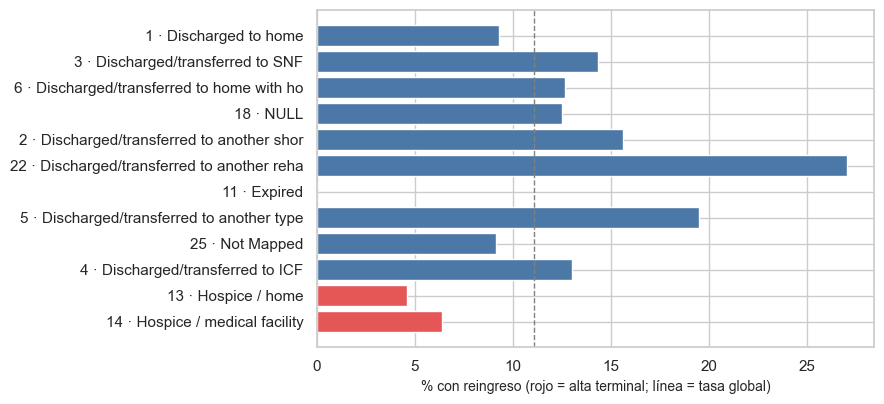

In [4]:
labels = discharge_labels()
term_ids = terminal_disposition_ids()
d = train.groupby("discharge_disposition_id")[TARGET].agg(["count", "mean"]).rename(columns={"count": "encuentros", "mean": "tasa de reingreso"})
d["descripción"] = [labels.get(int(i), "") for i in d.index]
d["terminal"] = d.index.isin(term_ids)
d = d.sort_values("encuentros", ascending=False)
mostrar = pd.concat([d.head(10), d[d["terminal"]]]).drop_duplicates()
display(mostrar.assign(**{"tasa de reingreso": mostrar["tasa de reingreso"].round(3)}))

fig, ax = plt.subplots(figsize=(9, 4.2))
t = pd.concat([d.head(10), d[d["terminal"] & (d["encuentros"] >= 20)]]).drop_duplicates().iloc[::-1]
ax.barh([f"{i} · {str(desc)[:38]}" for i, desc in zip(t.index, t["descripción"])], t["tasa de reingreso"] * 100,
        color=np.where(t["terminal"], "#e45756", "#4c78a8"))
ax.axvline(100 * y.mean(), color="gray", ls="--", lw=1); ax.set_xlabel("% con reingreso (rojo = alta terminal; línea = tasa global)")
plt.tight_layout(); save_figure(fig, "07_altas_terminales.png"); plt.show()

In [5]:
mask_t = train["discharge_disposition_id"].isin(term_ids)
n_t, rate_t, rate_resto = int(mask_t.sum()), float(y[mask_t].mean()) if mask_t.any() else np.nan, float(y[~mask_t].mean())
excluir = bool(n_t > 0 and rate_t < 0.02)
decision = pd.DataFrame([{"excluir_terminales": excluir, "codigos": ",".join(map(str, term_ids)), "n_excluidos_train": n_t,
                          "pct_excluidos": 100 * n_t / len(train), "tasa_reingreso_terminales": rate_t, "tasa_reingreso_resto": rate_resto,
                          "criterio": "excluir si hay altas terminales y su tasa de reingreso es < 2 %"}])
decision.to_csv(TABLES / "decision_poblacion.csv", index=False)
md_out(f"Códigos terminales: `{term_ids}`. Encuentros en entrenamiento: **{es(n_t, 0)}** ({es(n_t / len(train), 2, pct=True)}); tasa de reingreso: **{es(rate_t, 2, pct=True)}** "
       f"frente a {es(rate_resto, 1, pct=True)} en el resto.\n\n"
       + (f"**Decisión (criterio fijado antes de mirar el resultado: excluir si la tasa es < 2 %):** se **excluyen** estos encuentros de la población de modelado. "
          "La regla es clínica (no pueden reingresar), no estadística, y se aplica **después** de la partición, así que la prueba no se contamina. "
          "Los capítulos 8 y 9 leen esta decisión." if excluir else
          "**Decisión:** la tasa no es cercana a cero, así que se conservan los encuentros y se documenta la limitación."))

Códigos terminales: `[11, 13, 14, 19, 20, 21]`. Encuentros en entrenamiento: **1.940** (2,38 %); tasa de reingreso: **1,75 %** frente a 11,3 % en el resto.

**Decisión (criterio fijado antes de mirar el resultado: excluir si la tasa es < 2 %):** se **excluyen** estos encuentros de la población de modelado. La regla es clínica (no pueden reingresar), no estadística, y se aplica **después** de la partición, así que la prueba no se contamina. Los capítulos 8 y 9 leen esta decisión.

## 4. Duplicados y entidades repetidas entre particiones

Se comprueba que ningún paciente esté en entrenamiento y prueba a la vez, se compara con lo que ocurriría con una partición al azar de filas y se
mide cuánto se parecen los resultados de un mismo paciente (dependencia que justifica la validación por grupos).

In [6]:
test_full = load_test(include_terminal=True)
test_ids = set(test_full[GROUP_COL])
overlap = len(set(groups) & test_ids)

predictor_cols = [c for c in train.columns if c not in {ID_COL, GROUP_COL, RAW_TARGET, TARGET}]
train_hash = pd.util.hash_pandas_object(train[predictor_cols], index=False)
test_hash = pd.util.hash_pandas_object(test_full[predictor_cols], index=False)
shared = set(train_hash.unique()) & set(test_hash.unique())
duplicate_audit = pd.DataFrame([
    {"comprobación": "duplicados exactos dentro de training", "resultado": int(train[predictor_cols].duplicated().sum())},
    {"comprobación": "duplicados exactos dentro de test", "resultado": int(test_full[predictor_cols].duplicated().sum())},
    {"comprobación": "patrones predictores compartidos train/test", "resultado": len(shared)},
    {"comprobación": "filas test afectadas por patrón compartido", "resultado": int(test_hash.isin(shared).sum())},
    {"comprobación": "pacientes compartidos train/test", "resultado": overlap},
])
duplicate_audit.to_csv(TABLES / "auditoria_duplicados.csv", index=False)
display(duplicate_audit)

rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(frame)); cut = int(0.8 * len(perm))
tr_i, va_i = perm[:cut], perm[cut:]
naive_share = frame.iloc[va_i][GROUP_COL].isin(set(frame.iloc[tr_i][GROUP_COL])).mean()
orden = frame.sort_values(ID_COL).copy(); orden["n"] = orden.groupby(GROUP_COL).cumcount()
par = orden[orden["n"] < 2].pivot(index=GROUP_COL, columns="n", values=TARGET).dropna()
phi = float(par[0].corr(par[1])) if len(par) > 10 else np.nan
md_out(f"La partición agrupada tiene **{overlap} pacientes compartidos**. Una partición aleatoria por filas contaminaría {es(naive_share, 1, pct=True)} de la validación. La correlación entre los resultados de los dos primeros encuentros de pacientes repetidos es {es(phi, 3)}, por lo que se mantiene la validación por grupos.")

,comprobación,resultado
0,duplicados exactos dentro de training,0
1,duplicados exactos dentro de test,0
2,patrones predictores compartidos train/test,0
3,filas test afectadas por patrón compartido,0
4,pacientes compartidos train/test,0


La partición agrupada tiene **0 pacientes compartidos**. Una partición aleatoria por filas contaminaría 41,6 % de la validación. La correlación entre los resultados de los dos primeros encuentros de pacientes repetidos es 0,037, por lo que se mantiene la validación por grupos.

## 5. Conclusión de la auditoría

In [7]:
final = disp.merge(todo[["variable", "AUC univariado", "alerta"]], on="variable", how="left")
final["posible_proxy_del_target"] = np.where(
    final.variable.isin([RAW_TARGET, TARGET]), "Sí: contiene o deriva directamente del target",
    np.where(final["AUC univariado"].gt(0.75), "Requiere revisión por señal univariada alta", "Sin evidencia cuantitativa directa")
)
final["riesgo_de_leakage"] = np.select([
    final.variable.isin([RAW_TARGET, TARGET]),
    final.variable.isin([ID_COL, GROUP_COL]),
    final.variable.eq("discharge_disposition_id"),
    final["disponible_al_momento_de_prediccion"].eq("Revisar"),
], ["Alto", "Alto si se usara como predictor", "Medio", "Medio"], default="Bajo observable")

def decision_variable(row):
    v = row.variable
    if v in (RAW_TARGET, TARGET): return "Excluir del conjunto X"
    if v == ID_COL: return "Excluir; identificador"
    if v == GROUP_COL: return "Usar solo para agrupación"
    if v == "discharge_disposition_id": return "Conservar tras excluir altas terminales; documentar"
    if v in ("diag_1", "diag_2", "diag_3"): return "No usar cruda; sustituir por grupo CIE-9"
    if v in ("diag_1_grupo", "diag_2_grupo", "diag_3_grupo"): return "Conservar; validar disponibilidad local"
    return "Conservar como candidata"

final["decision"] = final.apply(decision_variable, axis=1)
final["justificacion"] = final.apply(
    lambda r: r.evidencia_temporal + (f" AUC univariado={r['AUC univariado']:.3f}." if pd.notna(r["AUC univariado"]) else " No se calcula AUC porque no entra directamente al modelo."), axis=1
)
final = final[["variable", "AUC univariado", "disponible_al_momento_de_prediccion", "posible_proxy_del_target", "riesgo_de_leakage", "decision", "justificacion"]]
final.to_csv(TABLES / "auditoria_fuga.csv", index=False)
display(final[final["riesgo_de_leakage"] != "Bajo observable"].round(3))
md_out("**Conclusión:** identificadores y objetivos quedan fuera de X; `patient_nbr` solo agrupa. Los diagnósticos se usan agrupados y quedan sujetos a confirmación temporal. No hay pacientes compartidos ni predictoras con AUC sospechosamente cercano a 1. La ausencia de evidencia observable no elimina el riesgo residual de metadatos clínicos incompletos.")

,variable,AUC univariado,disponible_al_momento_de_prediccion,posible_proxy_del_target,riesgo_de_leakage,decision,justificacion
0,encounter_id,0.507,No,Sin evidencia cuantitativa directa,Alto si se usara como predictor,Excluir; identificador,Identificador del encuentro; puede codificar orden o sistema y no ...
1,patient_nbr,0.511,Solo agrupar,Sin evidencia cuantitativa directa,Alto si se usara como predictor,Usar solo para agrupación,"Identifica al paciente para split, CV y bootstrap; nunca entra al ..."
7,discharge_disposition_id,0.575,"Sí, con cautela",Sin evidencia cuantitativa directa,Medio,Conservar tras excluir altas terminales; documentar,"Se conoce al alta, pero puede identificar fallecimiento u hospicio..."
18,diag_1,NaN,Revisar,Sin evidencia cuantitativa directa,Medio,No usar cruda; sustituir por grupo CIE-9,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
19,diag_2,NaN,Revisar,Sin evidencia cuantitativa directa,Medio,No usar cruda; sustituir por grupo CIE-9,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
20,diag_3,NaN,Revisar,Sin evidencia cuantitativa directa,Medio,No usar cruda; sustituir por grupo CIE-9,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
49,readmitted,1.000,No,Sí: contiene o deriva directamente del target,Alto,Excluir del conjunto X,Es la fuente directa del objetivo futuro. AUC univariado=1.000.
50,reingreso_30d,1.000,No,Sí: contiene o deriva directamente del target,Alto,Excluir del conjunto X,Es la variable objetivo derivada. AUC univariado=1.000.
52,diag_1_grupo,0.521,Revisar,Sin evidencia cuantitativa directa,Medio,Conservar; validar disponibilidad local,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...
53,diag_2_grupo,0.507,Revisar,Sin evidencia cuantitativa directa,Medio,Conservar; validar disponibilidad local,Diagnóstico registrado al cierre del encuentro; debe confirmarse q...


**Conclusión:** identificadores y objetivos quedan fuera de X; `patient_nbr` solo agrupa. Los diagnósticos se usan agrupados y quedan sujetos a confirmación temporal. No hay pacientes compartidos ni predictoras con AUC sospechosamente cercano a 1. La ausencia de evidencia observable no elimina el riesgo residual de metadatos clínicos incompletos.